# Análise exploratória — Dados Abertos CNPJ (safra 2026-06)

Fonte: `rfb.duckdb` (views sobre o Parquet gerado pelo pipeline deste repo).
Universo: **68,6M empresas**, **71,9M estabelecimentos**, **27,8M vínculos societários**, **49M registros do Simples**.

Todas as consultas rodam no DuckDB (agregação no banco, só o resultado vem pro pandas).

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

con = duckdb.connect(str(Path("..") / "rfb.duckdb"), read_only=True)
con.execute("SET memory_limit='12GB'")
con.execute("SET threads=4")

# --- estilo (paleta e cromo de gráfico) ---
AZUL      = "#2a78d6"   # série principal
AQUA      = "#1baf7a"   # série secundária
AMARELO   = "#eda100"
VERMELHO  = "#e34948"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
SURFACE   = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "font.size": 10.5,
    "font.family": "sans-serif",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 110,
})


def eixo_limpo(ax, x=False):
    """Grade só no eixo do valor; baseline visível."""
    ax.grid(axis="x" if x else "y")
    ax.grid(False, axis="y" if x else "x")
    return ax


def fmt_milhoes(v, _):
    return f"{v/1e6:.0f}M" if v >= 1e6 else (f"{v/1e3:.0f}k" if v >= 1e3 else f"{v:.0f}")


## 1. Visão geral do universo

In [2]:
tabelas = ["empresas", "estabelecimentos", "socios", "simples",
           "cnaes", "municipios", "naturezas", "qualificacoes", "motivos", "paises"]
visao = con.sql("UNION ALL ".join(
    f"SELECT '{t}' AS tabela, count(*) AS linhas FROM {t} "
    for t in tabelas)).df()
visao["linhas"] = visao["linhas"].map("{:,.0f}".format)
visao

,tabela,linhas
0,empresas,"68,629,148"
1,estabelecimentos,"71,874,422"
2,socios,"27,838,448"
3,simples,"49,034,553"
4,cnaes,"1,359"
5,municipios,"5,572"
6,naturezas,91
7,qualificacoes,68
8,motivos,63
9,paises,255


## 2. Situação cadastral dos estabelecimentos

Quantos dos 71,9M de CNPJs (estabelecimentos) estão de fato ativos?

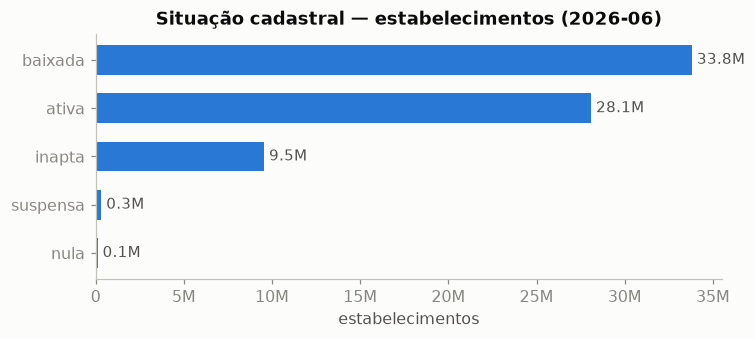

Ativos: 28,092,883 (39.1% do total)


In [3]:
sit = con.sql("""
    SELECT COALESCE(situacao, 'sem informacao') AS situacao, count(*) AS n
    FROM estabelecimentos_completos
    GROUP BY 1 ORDER BY n DESC
""").df()

fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(sit["situacao"], sit["n"], color=AZUL, height=0.62)
ax.invert_yaxis()
eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for b, v in zip(barras, sit["n"]):
    ax.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
            va="center", fontsize=10, color=INK_2)
ax.set_title("Situação cadastral — estabelecimentos (2026-06)")
ax.set_xlabel("estabelecimentos")
plt.tight_layout(); plt.show()

ativos = sit.loc[sit.situacao == "ativa", "n"].iloc[0]
print(f"Ativos: {ativos:,} ({ativos / sit.n.sum():.1%} do total)")

## 3. Estabelecimentos ativos por UF

Concentração geográfica da atividade econômica formal.

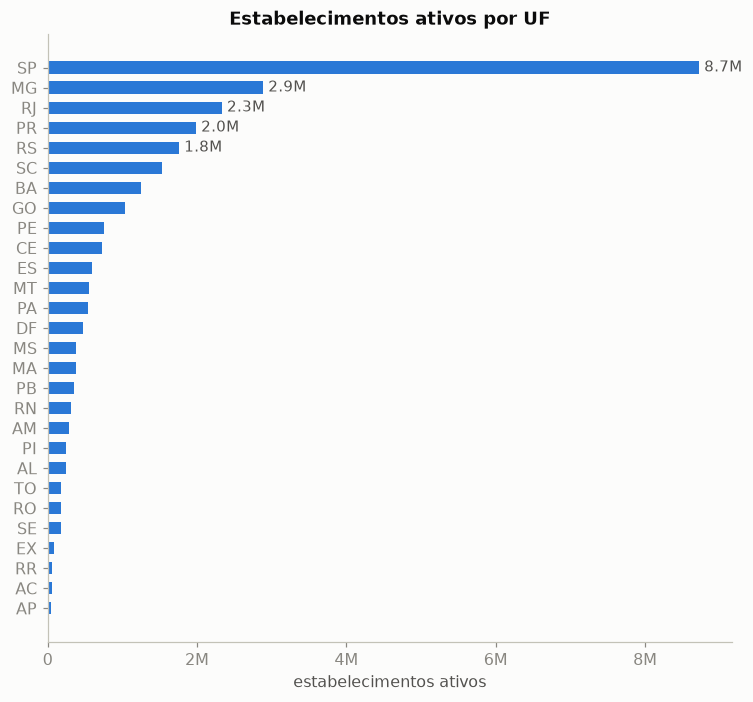

SP sozinho: 31.1% do total de ativos


In [4]:
uf = con.sql("""
    SELECT uf, count(*) AS n
    FROM estabelecimentos_completos
    WHERE situacao = 'ativa'
    GROUP BY uf ORDER BY n DESC
""").df()

fig, ax = plt.subplots(figsize=(7, 6.5))
barras = ax.barh(uf["uf"], uf["n"], color=AZUL, height=0.62)
ax.invert_yaxis()
eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for b, v in zip(barras[:5], uf["n"][:5]):
    ax.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
            va="center", fontsize=9.5, color=INK_2)
ax.set_title("Estabelecimentos ativos por UF")
ax.set_xlabel("estabelecimentos ativos")
plt.tight_layout(); plt.show()

print(f"SP sozinho: {uf.n.iloc[0] / uf.n.sum():.1%} do total de ativos")

## 4. Atividades econômicas mais comuns (CNAE principal)

Top 15 entre estabelecimentos ativos.

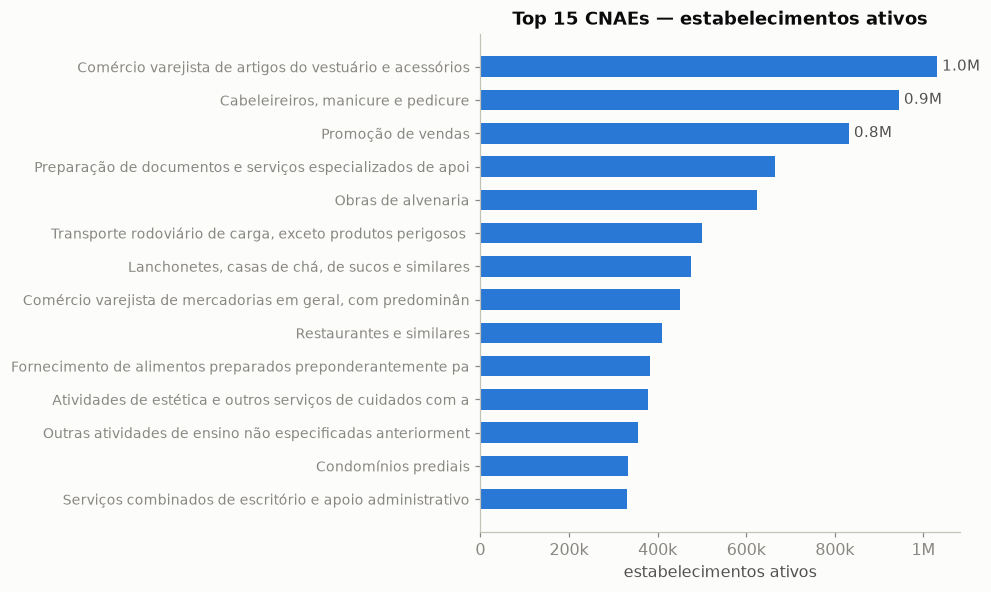

In [5]:
cnae = con.sql("""
    SELECT cnae_principal, count(*) AS n
    FROM estabelecimentos_completos
    WHERE situacao = 'ativa' AND cnae_principal IS NOT NULL
    GROUP BY cnae_principal ORDER BY n DESC LIMIT 15
""").df()
cnae["rotulo"] = cnae["cnae_principal"].str.slice(0, 58)

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = ax.barh(cnae["rotulo"], cnae["n"], color=AZUL, height=0.62)
ax.invert_yaxis()
eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for b, v in zip(barras[:3], cnae["n"][:3]):
    ax.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
            va="center", fontsize=9.5, color=INK_2)
ax.set_title("Top 15 CNAEs — estabelecimentos ativos")
ax.set_xlabel("estabelecimentos ativos")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()

## 5. Aberturas por ano

`data_inicio_atividade` (AAAAMMDD) agregada por ano — série histórica da
formalização. Corte em 1985+ (antes disso o volume é residual e há datas
inconsistentes).

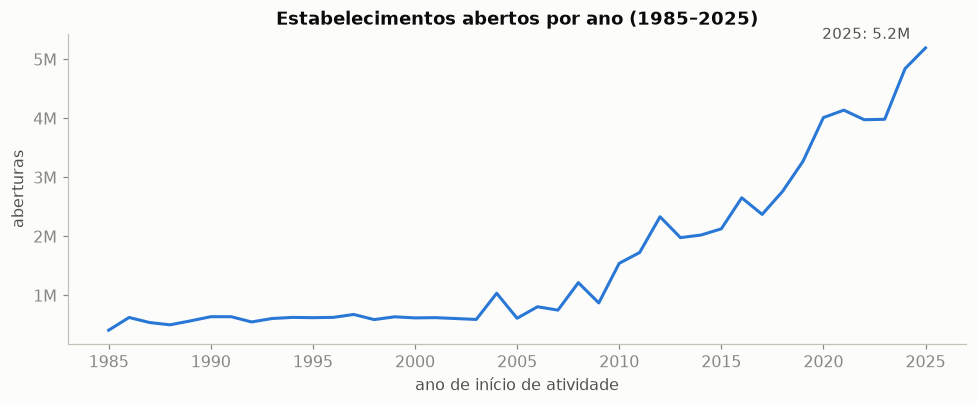

In [6]:
abert = con.sql("""
    SELECT CAST(substr(data_inicio_atividade, 1, 4) AS INT) AS ano, count(*) AS n
    FROM estabelecimentos
    WHERE length(data_inicio_atividade) = 8
      AND substr(data_inicio_atividade, 1, 4) BETWEEN '1985' AND '2025'
    GROUP BY ano ORDER BY ano
""").df()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(abert["ano"], abert["n"], color=AZUL, linewidth=2)
eixo_limpo(ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
pico = abert.loc[abert.n.idxmax()]
ax.annotate(f"{int(pico.ano)}: {pico.n/1e6:.1f}M", (pico.ano, pico.n),
            textcoords="offset points", xytext=(-10, 6),
            ha="right", fontsize=10, color=INK_2)
ax.set_title("Estabelecimentos abertos por ano (1985–2025)")
ax.set_xlabel("ano de início de atividade")
ax.set_ylabel("aberturas")
plt.tight_layout(); plt.show()

## 6. Porte e regime tributário

Distribuição de porte (empresas) e adesão a Simples/MEI.

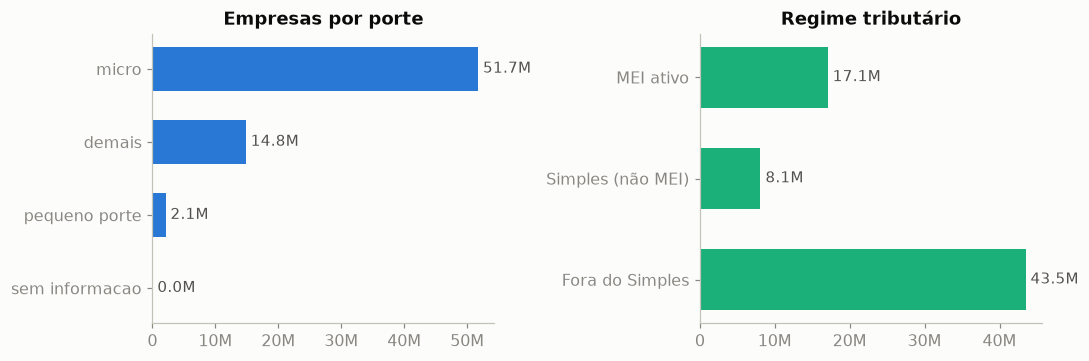

In [7]:
porte = con.sql("""
    SELECT COALESCE(porte, 'sem informacao') AS porte, count(*) AS n
    FROM empresas_completas GROUP BY 1 ORDER BY n DESC
""").df()

regime = con.sql("""
    SELECT
        count(*) FILTER (opcao_mei = 'S')                          AS "MEI ativo",
        count(*) FILTER (opcao_simples = 'S' AND (opcao_mei IS NULL OR opcao_mei <> 'S')) AS "Simples (não MEI)",
        count(*) FILTER (COALESCE(opcao_simples,'N') <> 'S' AND COALESCE(opcao_mei,'N') <> 'S') AS "Fora do Simples"
    FROM empresas_completas
""").df().T.reset_index()
regime.columns = ["regime", "n"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4))
b1 = a1.barh(porte["porte"], porte["n"], color=AZUL, height=0.6)
a1.invert_yaxis(); eixo_limpo(a1, x=True)
a1.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for b, v in zip(b1, porte["n"]):
    a1.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
            va="center", fontsize=9.5, color=INK_2)
a1.set_title("Empresas por porte")

b2 = a2.barh(regime["regime"], regime["n"], color=AQUA, height=0.6)
a2.invert_yaxis(); eixo_limpo(a2, x=True)
a2.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for b, v in zip(b2, regime["n"]):
    a2.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
            va="center", fontsize=9.5, color=INK_2)
a2.set_title("Regime tributário")
plt.tight_layout(); plt.show()

## 7. Perfil dos sócios

Faixa etária (pré-calculada pela RFB) e tipo de sócio. CPF já vem mascarado
na origem (`***XXXXXX**`).

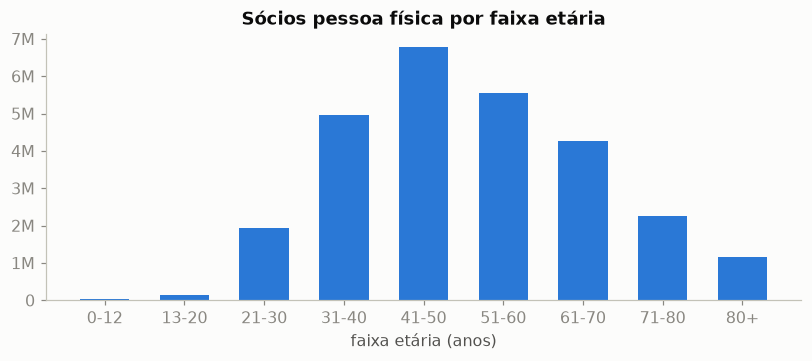

,tipo_socio,n,participacao
0,pessoa fisica,"27,115,693",97.4%
1,pessoa juridica,"709,926",2.6%
2,estrangeiro,"12,829",0.0%


In [8]:
faixa = con.sql("""
    SELECT faixa_etaria, count(*) AS n
    FROM socios_completos
    WHERE tipo_socio = 'pessoa fisica' AND faixa_etaria <> 'nao se aplica'
    GROUP BY faixa_etaria
    ORDER BY CASE faixa_etaria
        WHEN '0-12' THEN 1 WHEN '13-20' THEN 2 WHEN '21-30' THEN 3
        WHEN '31-40' THEN 4 WHEN '41-50' THEN 5 WHEN '51-60' THEN 6
        WHEN '61-70' THEN 7 WHEN '71-80' THEN 8 WHEN '80+' THEN 9 END
""").df()

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(faixa["faixa_etaria"], faixa["n"], color=AZUL, width=0.62)
eixo_limpo(ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
ax.set_title("Sócios pessoa física por faixa etária")
ax.set_xlabel("faixa etária (anos)")
plt.tight_layout(); plt.show()

tipo = con.sql("""
    SELECT tipo_socio, count(*) AS n FROM socios_completos GROUP BY 1 ORDER BY n DESC
""").df()
tipo["participacao"] = (tipo.n / tipo.n.sum()).map("{:.1%}".format)
tipo["n"] = tipo["n"].map("{:,.0f}".format)
tipo

## 8. Capital social por porte

`capital_social` vem como texto com vírgula decimal — conversão no SQL.
Mediana e p90 por porte (média é inútil aqui: outliers de bilhões).

In [9]:
capital = con.sql("""
    SELECT COALESCE(porte, 'sem informacao') AS porte,
           count(*)                                                      AS empresas,
           median(CAST(replace(capital_social, ',', '.') AS DOUBLE))     AS mediana,
           quantile_cont(CAST(replace(capital_social, ',', '.') AS DOUBLE), 0.9) AS p90
    FROM empresas_completas
    WHERE capital_social IS NOT NULL AND capital_social <> ''
    GROUP BY 1 ORDER BY mediana
""").df()
capital["empresas"] = capital["empresas"].map("{:,.0f}".format)
capital["mediana"] = capital["mediana"].map("R$ {:,.0f}".format)
capital["p90"] = capital["p90"].map("R$ {:,.0f}".format)
capital

,porte,empresas,mediana,p90
0,sem informacao,"4,063",R$ 0,R$ 0
1,demais,"14,826,270",R$ 0,"R$ 5,000"
2,micro,"51,718,445","R$ 3,000","R$ 40,000"
3,pequeno porte,"2,080,370","R$ 50,000","R$ 300,000"


## 9. Matriz × filial e idade média por situação

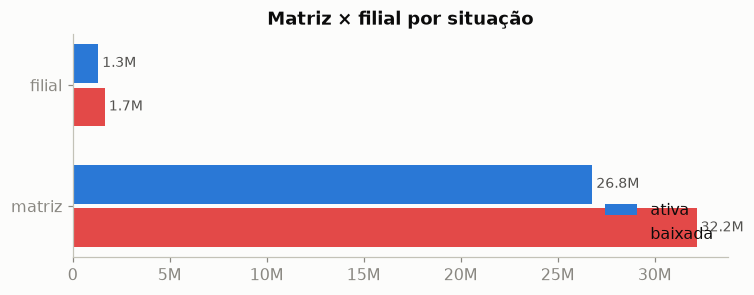

In [10]:
mf = con.sql("""
    SELECT COALESCE(matriz_filial, 'sem informacao') AS matriz_filial, situacao, count(*) AS n
    FROM estabelecimentos_completos
    WHERE situacao IN ('ativa', 'baixada')
    GROUP BY 1, 2 ORDER BY 1, 2
""").df().pivot(index="matriz_filial", columns="situacao", values="n")

fig, ax = plt.subplots(figsize=(7, 2.8))
y = range(len(mf))
h = 0.36
b1 = ax.barh([i - h/2 for i in y], mf["ativa"],   height=h - 0.04, color=AZUL,     label="ativa")
b2 = ax.barh([i + h/2 for i in y], mf["baixada"], height=h - 0.04, color=VERMELHO, label="baixada")
ax.set_yticks(list(y)); ax.set_yticklabels(mf.index)
ax.invert_yaxis(); eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_milhoes))
for barras in (b1, b2):
    for b in barras:
        v = b.get_width()
        ax.text(v, b.get_y() + b.get_height()/2, f" {v/1e6:.1f}M",
                va="center", fontsize=9, color=INK_2)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Matriz × filial por situação")
plt.tight_layout(); plt.show()

## Síntese

- Menos da metade dos 71,9M de estabelecimentos está **ativa** — o CNPJ acumula
  histórico de baixados desde sempre.
- **SP concentra ~1/4** dos ativos; SP+MG+RJ+PR+RS passam de metade.
- O top de CNAEs é dominado por atividades típicas de **MEI** (comércio varejista,
  cabeleireiros, obras) — consistente com o peso do MEI no regime tributário.
- Aberturas **aceleram forte pós-2010** (efeito MEI, criado em 2009).
- Sócios concentrados entre **31 e 60 anos**.

Próximos recortes possíveis: evolução multi-safra (quando houver mais meses),
mapa por município, sobrevivência (idade na baixa), CNAEs secundários (split da
`cnae_fiscal_secundaria`).